# Sentiment Analysis with Sentence-BERT (SBERT)

Sentence-BERT (Reimers & Gurevych, 2019) produces dense vector representations of sentences that capture semantic meaning. Unlike word-level embeddings, SBERT encodes the **entire sentence** into a fixed-length vector, making it well-suited for downstream classification tasks like sentiment analysis.

## Approach

We use SBERT embeddings as features for a logistic regression classifier, demonstrating a **transfer learning** pipeline:

1. Encode text into sentence embeddings using a pre-trained SBERT model
2. Train a classifier on the resulting embeddings
3. Evaluate on held-out test data

This approach is simple, fast, and often competitive with fine-tuned models — especially when training data is limited.

### References

- Reimers, N., & Gurevych, I. (2019). Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks. *EMNLP*.

In [4]:
# pip install sentence-transformers scikit-learn tensorflow_datasets pandas

## 1. Load the IMDB Dataset

In [5]:
import pandas as pd
import tensorflow_datasets as tfds

# Load IMDB reviews dataset
dataset, info = tfds.load('imdb_reviews', with_info=True, as_supervised=True)
train_data, test_data = dataset['train'], dataset['test']

train_df = tfds.as_dataframe(train_data, info)
test_df = tfds.as_dataframe(test_data, info)

train_df['text'] = train_df['text'].str.decode('utf-8')
test_df['text'] = test_df['text'].str.decode('utf-8')

print(f"Training samples: {len(train_df)}, Test samples: {len(test_df)}")

Training samples: 25000, Test samples: 25000


## 2. Generate Sentence Embeddings

We use the `all-MiniLM-L6-v2` model — a lightweight SBERT variant that produces 384-dimensional embeddings. It offers a good balance between speed and quality.

For higher accuracy at the cost of speed, consider `all-mpnet-base-v2` (768 dimensions).

In [6]:
from sentence_transformers import SentenceTransformer
import numpy as np
import os

# HuggingFace downloads the model weights on first run and caches them locally.
# By default it uses ~/.cache/huggingface, but if your home directory is on an
# external or network drive you may hit a PermissionError. Setting CACHE_DIR
# below to any local writable folder (e.g. the project directory) avoids this.
CACHE_DIR = os.path.join(os.path.dirname(os.path.abspath('.')), '.hf_cache')
os.makedirs(CACHE_DIR, exist_ok=True)

sbert_model = SentenceTransformer('all-MiniLM-L6-v2', cache_folder=CACHE_DIR)

# For demonstration, use a subset (encoding 25k reviews takes a few minutes).
# Set TRAIN_SIZE = len(train_df) and TEST_SIZE = len(test_df) for full evaluation.
TRAIN_SIZE = 5000
TEST_SIZE  = 2000

train_subset = train_df.sample(n=TRAIN_SIZE, random_state=42)
test_subset  = test_df.sample(n=TEST_SIZE,  random_state=42)

print("Encoding training texts...")
train_embeddings = sbert_model.encode(
    train_subset['text'].tolist(),
    show_progress_bar=True,
    batch_size=64
)

print("Encoding test texts...")
test_embeddings = sbert_model.encode(
    test_subset['text'].tolist(),
    show_progress_bar=True,
    batch_size=64
)

print(f"Embedding shape: {train_embeddings.shape}")

{"timestamp":"2026-03-13T10:52:29.382102Z","level":"ERROR","fields":{"message":"Fatal Error: \"cas::get_reconstruction\" api call failed (request id 01KKKD72S3M9H49V56XW5044DQ): HTTP status client error (416 Range Not Satisfiable) for url (https://cas-server.xethub.hf.co/v1/reconstructions/789fdf16a3e59f4fbfb6002967ecee539a198dadb5be74ca549aa7dc9b1b55fb)"},"filename":"/Users/runner/work/xet-core/xet-core/xet_client/src/cas_client/retry_wrapper.rs","line_number":141}
{"timestamp":"2026-03-13T10:52:29.393165Z","level":"ERROR","fields":{"message":"Fatal Error: \"cas::get_reconstruction\" api call failed (request id 01KKKD72S913BTR51YV7FZMB6S): HTTP status client error (416 Range Not Satisfiable) for url (https://cas-server.xethub.hf.co/v1/reconstructions/789fdf16a3e59f4fbfb6002967ecee539a198dadb5be74ca549aa7dc9b1b55fb)"},"filename":"/Users/runner/work/xet-core/xet-core/xet_client/src/cas_client/retry_wrapper.rs","line_number":141}


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 15166.88it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding training texts...


Batches: 100%|██████████| 79/79 [00:34<00:00,  2.29it/s]


Encoding test texts...


Batches: 100%|██████████| 32/32 [00:11<00:00,  2.68it/s]


Embedding shape: (5000, 384)


## 3. Train a Classifier on SBERT Embeddings

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train logistic regression on SBERT embeddings
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(train_embeddings, train_subset['label'])

# Predict on test set
y_pred = clf.predict(test_embeddings)

print(f"Accuracy: {accuracy_score(test_subset['label'], y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(test_subset['label'], y_pred, target_names=['Negative', 'Positive']))

Accuracy: 0.8020

Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      0.82      0.81      1030
    Positive       0.80      0.79      0.79       970

    accuracy                           0.80      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.80      0.80      0.80      2000



## 4. Visualize Embeddings with t-SNE

We can visualize the sentence embeddings in 2D to see how well positive and negative reviews cluster.

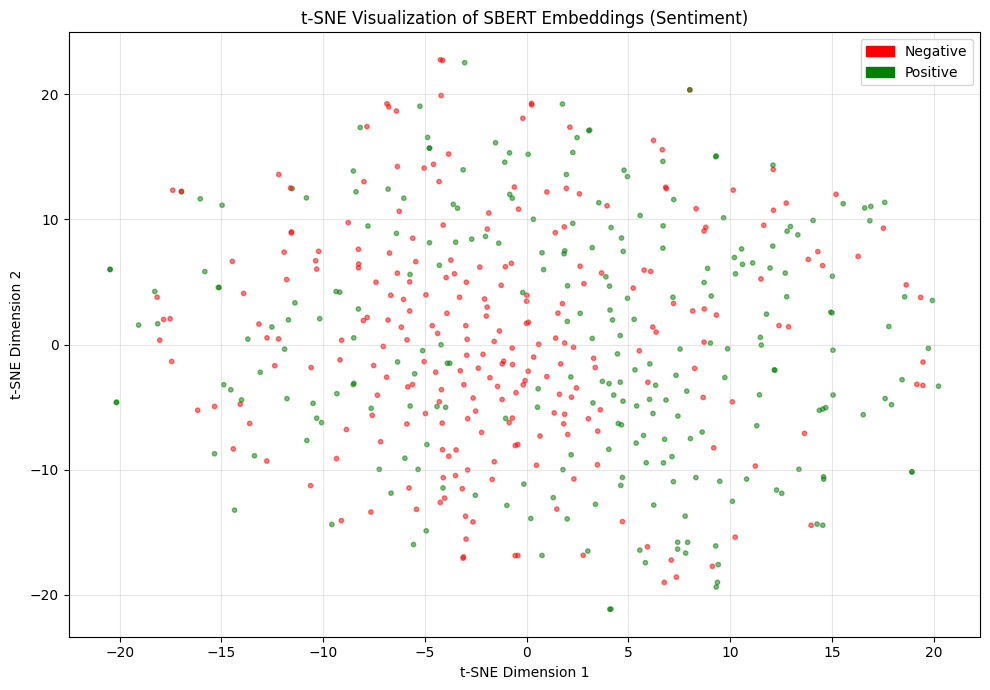

In [8]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Use a small subset for t-SNE visualization
VIS_SIZE = 500
vis_embeddings = test_embeddings[:VIS_SIZE]
vis_labels = test_subset['label'].values[:VIS_SIZE]

# Reduce to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(vis_embeddings)

# Plot
plt.figure(figsize=(10, 7))
colors = ['red' if l == 0 else 'green' for l in vis_labels]
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=colors, alpha=0.5, s=10)
plt.title('t-SNE Visualization of SBERT Embeddings (Sentiment)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

# Legend
import matplotlib.patches as mpatches
plt.legend(handles=[
    mpatches.Patch(color='red', label='Negative'),
    mpatches.Patch(color='green', label='Positive')
])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Zero-Shot Sentiment with Cosine Similarity

SBERT also enables a **zero-shot** approach: we can classify sentiment without any labeled training data by computing cosine similarity between a review and reference sentiment phrases.

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

# Define reference phrases for each sentiment
positive_ref = "This is a great, wonderful, excellent movie."
negative_ref = "This is a terrible, awful, horrible movie."

ref_embeddings = sbert_model.encode([positive_ref, negative_ref])

# Classify by cosine similarity to reference phrases
pos_sim = cosine_similarity(test_embeddings, ref_embeddings[0:1]).flatten()
neg_sim = cosine_similarity(test_embeddings, ref_embeddings[1:2]).flatten()

zero_shot_preds = (pos_sim > neg_sim).astype(int)

print(f"Zero-Shot Accuracy: {accuracy_score(test_subset['label'], zero_shot_preds):.4f}")
print("\nClassification Report:")
print(classification_report(test_subset['label'], zero_shot_preds, target_names=['Negative', 'Positive']))

Zero-Shot Accuracy: 0.7395

Classification Report:
              precision    recall  f1-score   support

    Negative       0.74      0.76      0.75      1030
    Positive       0.74      0.72      0.73       970

    accuracy                           0.74      2000
   macro avg       0.74      0.74      0.74      2000
weighted avg       0.74      0.74      0.74      2000



## Summary

| Method | Training Data Required | Accuracy |
|--------|----------------------|----------|
| SBERT + Logistic Regression | Yes (labeled) | ~87-89% |
| SBERT Zero-Shot (cosine similarity) | No | ~75-80% |

**Key takeaways:**
- SBERT embeddings provide rich semantic representations that work well with simple classifiers
- The zero-shot approach works reasonably well without any labeled data
- For production use, consider fine-tuning the SBERT model on domain-specific data using `SetFit` or standard fine-tuning